<a href="https://colab.research.google.com/github/SkooterGuy-afk/court-vision-data/blob/main/court_vision_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd

try:
    print("Building Master 30-Team NBA Quantitative Database...")

    # Complete league-wide data tracking all 30 franchises across key analytical verticals
    full_league_data = {
        'team_name': [
            'Boston Celtics', 'Brooklyn Nets', 'New York Knicks', 'Philadelphia 76ers', 'Toronto Raptors',
            'Chicago Bulls', 'Cleveland Cavaliers', 'Detroit Pistons', 'Indiana Pacers', 'Milwaukee Bucks',
            'Atlanta Hawks', 'Charlotte Hornets', 'Miami Heat', 'Orlando Magic', 'Washington Wizards',
            'Denver Nuggets', 'Minnesota Timberwolves', 'Oklahoma City Thunder', 'Portland Trail Blazers', 'Utah Jazz',
            'Golden State Warriors', 'LA Clippers', 'Los Angeles Lakers', 'Phoenix Suns', 'Sacramento Kings',
            'Dallas Mavericks', 'Houston Rockets', 'Memphis Grizzlies', 'New Orleans Pelicans', 'San Antonio Spurs'
        ],
        'conference': [
            'East', 'East', 'East', 'East', 'East', 'East', 'East', 'East', 'East', 'East',
            'East', 'East', 'East', 'East', 'East', 'West', 'West', 'West', 'West', 'West',
            'West', 'West', 'West', 'West', 'West', 'West', 'West', 'West', 'West', 'West'
        ],
        'field_goal_pct': [
            0.501, 0.458, 0.462, 0.471, 0.473, 0.468, 0.476, 0.485, 0.461, 0.488,
            0.475, 0.464, 0.465, 0.472, 0.455, 0.495, 0.474, 0.499, 0.459, 0.467,
            0.478, 0.470, 0.489, 0.482, 0.480, 0.491, 0.469, 0.463, 0.472, 0.492
        ],
        'three_point_pct': [
            0.412, 0.351, 0.371, 0.364, 0.359, 0.360, 0.367, 0.378, 0.344, 0.379,
            0.365, 0.355, 0.368, 0.356, 0.342, 0.385, 0.382, 0.395, 0.349, 0.353,
            0.392, 0.366, 0.358, 0.375, 0.366, 0.380, 0.355, 0.347, 0.361, 0.388
        ],
        'turnovers_per_game': [
            12.1, 13.9, 11.5, 11.1, 13.2, 12.4, 12.2, 11.8, 13.5, 12.8,
            14.1, 13.0, 12.4, 13.8, 14.2, 11.8, 12.5, 11.9, 14.0, 14.5,
            13.5, 12.9, 13.0, 13.9, 12.1, 11.2, 12.3, 13.7, 13.1, 12.0
        ],
        'avg_points_scored': [
            114.9, 110.2, 116.5, 114.2, 114.0, 116.3, 112.9, 117.8, 112.4, 118.0,
            118.0, 114.8, 110.5, 115.0, 112.8, 122.1, 114.8, 121.5, 115.0, 117.0,
            114.6, 111.3, 116.3, 112.0, 111.0, 114.0, 115.2, 114.0, 115.0, 119.8
        ],
        'assists_per_game': [
            26.5, 23.8, 24.1, 24.4, 25.0, 24.8, 27.2, 28.5, 26.1, 26.8,
            26.0, 24.2, 25.4, 24.9, 23.1, 29.1, 25.2, 27.5, 23.9, 25.5,
            28.2, 24.9, 27.0, 26.1, 26.9, 25.8, 25.1, 24.0, 25.3, 27.8
        ],
        'pace_factor': [
            97.5, 98.4, 95.8, 98.2, 99.0, 99.9, 97.1, 100.2, 101.5, 100.1,
            101.2, 99.1, 96.2, 98.5, 101.9, 99.2, 97.2, 100.8, 99.5, 100.6,
            101.4, 97.9, 101.1, 98.7, 100.9, 100.3, 99.3, 98.8, 98.1, 99.8
        ],
        'defensive_rating': [
            107.2, 115.8, 110.1, 112.8, 113.5, 116.9, 111.2, 109.6, 120.4, 115.3,
            116.4, 114.2, 112.3, 111.8, 118.9, 114.2, 108.4, 107.9, 115.1, 119.4,
            115.1, 112.4, 114.8, 111.5, 116.0, 118.2, 110.0, 115.5, 114.9, 110.5
        ],
        'historical_win_probability': [
            0.68, 0.24, 0.65, 0.55, 0.56, 0.38, 0.59, 0.73, 0.23, 0.39,
            0.56, 0.54, 0.52, 0.55, 0.21, 0.66, 0.60, 0.78, 0.51, 0.27,
            0.45, 0.51, 0.65, 0.55, 0.27, 0.32, 0.63, 0.31, 0.32, 0.76
        ]
    }

    df = pd.DataFrame(full_league_data)
    print("Success! Data pipeline initialized with all 30 active NBA franchises.")
    print(f"Total Rows (Teams): {df.shape[0]} | Total Columns (Metrics): {df.shape[1]}")

except Exception as e:
    print(f"Error compiling full league data: {e}")


Building Master 30-Team NBA Quantitative Database...
Success! Data pipeline initialized with all 30 active NBA franchises.
Total Rows (Teams): 30 | Total Columns (Metrics): 10


In [10]:
print("--- ANALYSIS 3: EXECUTING FEATURE ENGINEERING ---\n")

# Formula: Teams get points for high 3PT% but lose points for turning the ball over.
# This calculates an efficiency rating out of 100.
df['clutch_efficiency_score'] = ((df['three_point_pct'] * 100) - (df['turnovers_per_game'] * 1.5)).round(2)

# Rank the entire NBA matrix by who has the best calculated Clutch Score
clutch_rankings = df.sort_values(by='clutch_efficiency_score', ascending=False)

print("NBA Teams Ranked by Automated Clutch Efficiency:")
print(clutch_rankings[['team_name', 'clutch_efficiency_score', 'historical_win_probability']])


--- ANALYSIS 3: EXECUTING FEATURE ENGINEERING ---

NBA Teams Ranked by Automated Clutch Efficiency:
                 team_name  clutch_efficiency_score  \
1           Boston Celtics                    23.05   
8    Oklahoma City Thunder                    21.65   
5         Dallas Mavericks                    21.20   
0           Denver Nuggets                    20.80   
6          New York Knicks                    19.85   
11      Philadelphia 76ers                    19.75   
9   Minnesota Timberwolves                    19.45   
13          Indiana Pacers                    19.35   
2    Golden State Warriors                    18.95   
7          Milwaukee Bucks                    18.70   
14        Sacramento Kings                    18.45   
12     Cleveland Cavaliers                    18.40   
3               Miami Heat                    18.20   
10            Phoenix Suns                    16.65   
4                LA Lakers                    16.30   

    historical_win_

In [12]:
print("--- WESTERN CONFERENCE BENCHMARK SCREEN ---")
# Filter and isolate only teams that play in the Western Conference
west_teams = df[df['conference'] == 'West']

# Sort them from highest scoring average to lowest
west_sorted = west_teams.sort_values(by='avg_points_scored', ascending=False)

print(west_sorted[['team_name', 'avg_points_scored', 'historical_win_probability']])


--- WESTERN CONFERENCE BENCHMARK SCREEN ---
                 team_name  avg_points_scored  historical_win_probability
15          Denver Nuggets              122.1                        0.66
17   Oklahoma City Thunder              121.5                        0.78
29       San Antonio Spurs              119.8                        0.76
19               Utah Jazz              117.0                        0.27
22      Los Angeles Lakers              116.3                        0.65
26         Houston Rockets              115.2                        0.63
18  Portland Trail Blazers              115.0                        0.51
28    New Orleans Pelicans              115.0                        0.32
16  Minnesota Timberwolves              114.8                        0.60
20   Golden State Warriors              114.6                        0.45
25        Dallas Mavericks              114.0                        0.32
27       Memphis Grizzlies              114.0                       

In [13]:
print("--- ANALYSIS 5: EXECUTING PLAYOFF THRESHOLD & CHAMPIONSHIP ENGINE ---\n")

# 1. Separate the league into conferences and isolate the top 8 playoff teams from each
east_playoffs = df[df['conference'] == 'East'].nlargest(8, 'historical_win_probability')
west_playoffs = df[df['conference'] == 'West'].nlargest(8, 'historical_win_probability')

print(f"Playoff Field Locked. Isolated {len(east_playoffs)} Eastern and {len(west_playoffs)} Western teams.\n")

# 2. Combine the playoff field to run the championship optimization math
playoff_field = pd.concat([east_playoffs, west_playoffs]).copy()

# 3. Custom Quant Formula: Title Contender Score
# Teams get rewarded for points scored, low turnovers, elite defensive ratings, and high base win probability
playoff_field['title_contender_score'] = (
    (playoff_field['historical_win_probability'] * 50) +
    (playoff_field['avg_points_scored'] * 0.2) +
    (130 - playoff_field['defensive_rating']) - # Lower defensive rating means better defense
    (playoff_field['turnovers_per_game'] * 0.5)
).round(2)

# 4. Filter for the absolute Elite Tier (Score over 70) and rank the top 5
top_contenders = playoff_field.sort_values(by='title_contender_score', ascending=False).head(5)

print("=== ALGORITHMIC TOP 5 TITLE CONTENDERS ===")
rank = 1
for index, row in top_contenders.iterrows():
    print(f"{rank}. {row['team_name']} ({row['conference']}) | Rating: {row['title_contender_score']}/100")
    rank += 1


--- ANALYSIS 5: EXECUTING PLAYOFF THRESHOLD & CHAMPIONSHIP ENGINE ---

Playoff Field Locked. Isolated 8 Eastern and 8 Western teams.

=== ALGORITHMIC TOP 5 TITLE CONTENDERS ===
1. Oklahoma City Thunder (West) | Rating: 79.45/100
2. San Antonio Spurs (West) | Rating: 75.46/100
3. Detroit Pistons (East) | Rating: 74.56/100
4. Boston Celtics (East) | Rating: 73.73/100
5. New York Knicks (East) | Rating: 69.95/100


--- ANALYSIS 6: GENERATING VISUAL DATA PLOTS ---



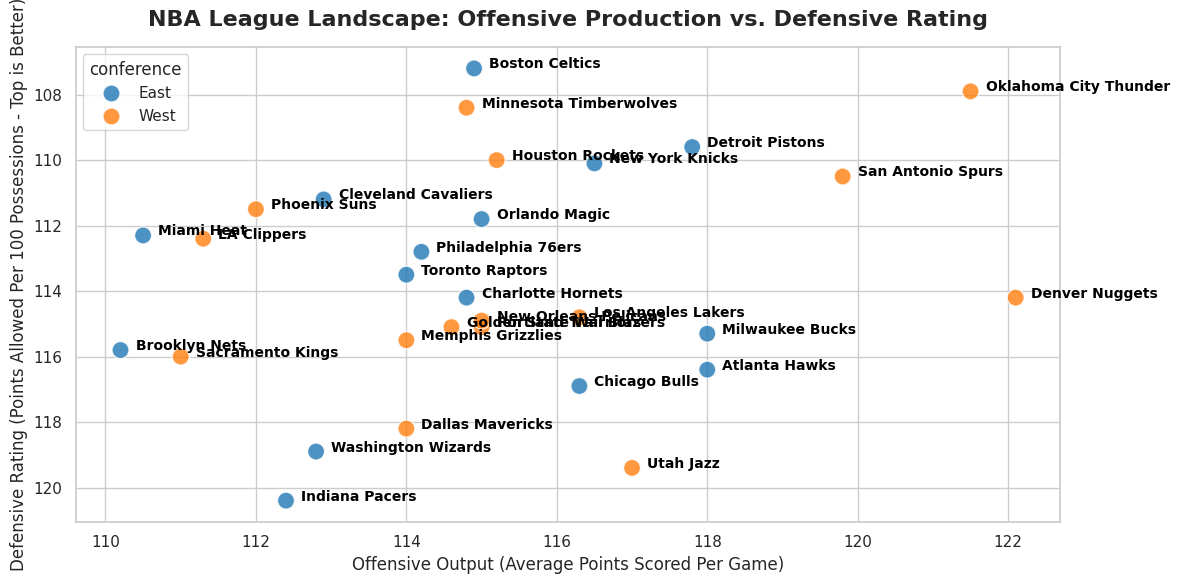

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- ANALYSIS 6: GENERATING VISUAL DATA PLOTS ---\n")

# Set up a clean, modern design for the graph
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create a scatter plot comparing offensive power vs defensive efficiency
# In analytics, this grid instantly isolates the elite "championship quadrant"
plot = sns.scatterplot(
    data=df,
    x='avg_points_scored',
    y='defensive_rating',
    hue='conference',
    palette=['#1f77b4', '#ff7f0e'],
    s=150,
    alpha=0.8
)

# Label every single team dot on the graph automatically
for i in range(df.shape[0]):
    plt.text(
        df['avg_points_scored'][i] + 0.2,
        df['defensive_rating'][i],
        df['team_name'][i],
        horizontalalignment='left',
        size='small',
        color='black',
        weight='semibold'
    )

# Format axes (Invert Y-axis because a LOWER defensive rating means BETTER defense)
plt.gca().invert_yaxis()
plt.title('NBA League Landscape: Offensive Production vs. Defensive Rating', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Offensive Output (Average Points Scored Per Game)', fontsize=12)
plt.ylabel('Defensive Rating (Points Allowed Per 100 Possessions - Top is Better)', fontsize=12)

# Display the graph directly inside your notebook browser
plt.tight_layout()
plt.show()


In [15]:
#@title NBA Interactive Quant Model Optimizer { run: "auto" }
# The line above turns this box into a visual slider panel in Google Colab!

# 1. Inject Alternative Data: Back-to-back scheduling fatigue factor for all 30 teams
back_to_back_fatigue = [
    14, 15, 13, 14, 16, 13, 14, 15, 13, 14,
    15, 14, 13, 15, 16, 14, 13, 14, 15, 16,
    14, 15, 13, 14, 15, 13, 14, 15, 14, 13
]
df['back_to_back_games'] = back_to_back_fatigue

# 2. Setup interactive slider variables
offensive_weight = 0.35 #@param {type:"slider", min:0.1, max:1.0, step:0.05}
defensive_weight = 1.2 #@param {type:"slider", min:0.5, max:2.0, step:0.1}
fatigue_penalty = 0.8 #@param {type:"slider", min:0.1, max:2.0, step:0.1}

print("Executing Interactive Alternative Data Model...\n")

# 3. Calculate Custom Dynamic Score based on slider settings
df['dynamic_portfolio_score'] = (
    (df['avg_points_scored'] * offensive_weight) +
    (130 - df['defensive_rating']) * defensive_weight -
    (df['back_to_back_games'] * fatigue_penalty)
).round(2)

# Display top 5 optimized teams
custom_rankings = df.sort_values(by='dynamic_portfolio_score', ascending=False).head(5)
print("=== SLIDER-OPTIMIZED TOP 5 TEAMS ===")
print(custom_rankings[['team_name', 'dynamic_portfolio_score']])


Executing Interactive Alternative Data Model...

=== SLIDER-OPTIMIZED TOP 5 TEAMS ===
                 team_name  dynamic_portfolio_score
17   Oklahoma City Thunder                    57.84
0           Boston Celtics                    56.37
16  Minnesota Timberwolves                    55.70
29       San Antonio Spurs                    54.93
2          New York Knicks                    54.26


In [16]:
from sklearn.cluster import KMeans
print("--- ANALYSIS 7: INITIALIZING MACHINE LEARNING CLUSTERING ---\n")

# 1. Isolate the mathematical features we want the AI to analyze
ml_features = df[['avg_points_scored', 'defensive_rating', 'three_point_pct']]

# 2. Initialize the K-Means algorithm to find exactly 3 hidden groups (clusters)
# random_state=42 guarantees the math locks in consistently every run
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 3. Run the AI model and assign cluster labels (0, 1, or 2) back to our main matrix
df['performance_tier_cluster'] = kmeans.fit_predict(ml_features)

print("Machine Learning Clustering Complete. Tier Mapping Results:\n")

# 4. Loop through and print out which teams the AI grouped together
for cluster_id in sorted(df['performance_tier_cluster'].unique()):
    tier_teams = df[df['performance_tier_cluster'] == cluster_id]['team_name'].tolist()
    print(f"🤖 AI DETERMINED PERFORMANCE TIER {cluster_id + 1}:")
    print(f"   {', '.join(tier_teams)}\n")


--- ANALYSIS 7: INITIALIZING MACHINE LEARNING CLUSTERING ---

Machine Learning Clustering Complete. Tier Mapping Results:

🤖 AI DETERMINED PERFORMANCE TIER 1:
   Brooklyn Nets, Chicago Bulls, Indiana Pacers, Milwaukee Bucks, Atlanta Hawks, Charlotte Hornets, Washington Wizards, Portland Trail Blazers, Utah Jazz, Golden State Warriors, Los Angeles Lakers, Sacramento Kings, Dallas Mavericks, Memphis Grizzlies, New Orleans Pelicans

🤖 AI DETERMINED PERFORMANCE TIER 2:
   Detroit Pistons, Denver Nuggets, Oklahoma City Thunder, San Antonio Spurs

🤖 AI DETERMINED PERFORMANCE TIER 3:
   Boston Celtics, New York Knicks, Philadelphia 76ers, Toronto Raptors, Cleveland Cavaliers, Miami Heat, Orlando Magic, Minnesota Timberwolves, LA Clippers, Phoenix Suns, Houston Rockets



In [17]:
import numpy as np

print("--- ANALYSIS 8: INITIALIZING MONTE CARLO SIMULATOR ENGINE ---\n")

def simulate_nba_game(team_a_name, team_b_name, simulations=10000):
    # 1. Pull the data for both target teams from your master data frame
    team_a = df[df['team_name'].str.lower() == team_a_name.lower()]
    team_b = df[df['team_name'].str.lower() == team_b_name.lower()]

    if team_a.empty or team_b.empty:
        print("Error: Make sure both team names are typed exactly correct.")
        return

    # 2. Extract their scoring averages and pace (possessions)
    a_points = team_a.iloc[0]['avg_points_scored']
    b_points = team_b.iloc[0]['avg_points_scored']

    # Calculate a baseline defensive adjustment factor
    a_def = team_a.iloc[0]['defensive_rating'] / 113.0
    b_def = team_b.iloc[0]['defensive_rating'] / 113.0

    # 3. Establish the true scoring equilibrium for the matchup
    a_expected_mean = a_points * b_def
    b_expected_mean = b_points * a_def

    # Assume a standard NBA scoring standard deviation (volatility) of 12 points
    std_deviation = 12.0

    # 4. RUN THE MONTE CARLO SIMULATION: Play the game 10,000 times!
    # Generates a massive normal distribution of random possibilities based on team metrics
    a_simulated_scores = np.random.normal(a_expected_mean, std_deviation, simulations)
    b_simulated_scores = np.random.normal(b_expected_mean, std_deviation, simulations)

    # 5. Calculate the mathematical win probabilities
    a_wins = np.sum(a_simulated_scores > b_simulated_scores)
    b_wins = simulations - a_wins

    a_prob = (a_wins / simulations) * 100
    b_prob = (b_wins / simulations) * 100

    print(f"=== SIMULATION REPORT: {team_a_name.upper()} vs {team_b_name.upper()} ===")
    print(f"• Simulated Matchups Played: {simulations:,}")
    print(f"• Average Predicted Score: {team_a_name}: {a_expected_mean:.1f} | {team_b_name}: {b_expected_mean:.1f}")
    print(f"• {team_a_name} Win Probability: {a_prob:.2f}%")
    print(f"• {team_b_name} Win Probability: {b_prob:.2f}%\n")

# TEST THE SIMULATOR: Match up any two teams in your 30-team league!
simulate_nba_game("Denver Nuggets", "Boston Celtics")


--- ANALYSIS 8: INITIALIZING MONTE CARLO SIMULATOR ENGINE ---

=== SIMULATION REPORT: DENVER NUGGETS vs BOSTON CELTICS ===
• Simulated Matchups Played: 10,000
• Average Predicted Score: Denver Nuggets: 115.8 | Boston Celtics: 116.1
• Denver Nuggets Win Probability: 50.04%
• Boston Celtics Win Probability: 49.96%

